In [37]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError
from matplotlib.gridspec import GridSpec

In [38]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
# TODO: Why empyrically picked 25?
BITS_HIT = 25 

In [39]:
def show_image(events: np.array) -> None:
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_patch(patch: np.array, title: str) -> None:
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.title(title)
    plt.show()
    
def _get_encoded_patch_bits(encoded_size,
                           patch_size,
                           module_rows=160,
                           module_cols=416):
    
    encoded_width, encoded_height, num_embeddings = encoded_size
    
    # np.log2(num_embeddings) - how many bits for specific codeword    
    vq_bits = encoded_width * encoded_height * np.log2(num_embeddings)
    
    # Patch address bits
    bits_patch_row = np.ceil(np.log2(np.ceil(module_rows / patch_size)))
    bits_patch_col = np.ceil(np.log2(np.ceil(module_cols / patch_size)))
    total = bits_patch_row + bits_patch_col + vq_bits
    
    # 267 % 256 = 11
    return total

def _get_total_hit_bits(total_hits: int) -> int:
    
    # Patch address bits
    return total_hits * BITS_HIT

"""
Method for getting patch bits

patch_amount - total detector patch count

encoded_patch_size - encoded_width, encoded_height, num_embeddings

patch_size - patch size
"""

def _get_total_patch_bits(patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> int:
    encoded_patch_bits = _get_encoded_patch_bits(encoded_patch_size, patch_size)
    return np.uint64(patch_amount * encoded_patch_bits)

def _get_compression_ratio(
        n_hits_total: int, 
        patch_amount: int, 
        encoded_patch_size: tuple, 
        patch_size: int
    ) -> float:
    total_bits = _get_total_hit_bits(n_hits_total)
    
    total_patch_bits = _get_total_patch_bits(
        patch_amount, 
        encoded_patch_size, 
        patch_size
    )
    return total_bits / total_patch_bits

def _get_patch_count(event: PixelDigiEvent) -> int:
    event_patches_adcs_flat = event_hits_to_patches(
        event, 
        patch_size=PATCH_SIZE
    ).as_array()
    return len(event_patches_adcs_flat)
    
# helper function
def _display_gradients(model: object) -> None:
    print("Showing model gradients")
    for name, param in model.named_parameters():
        if param.grad is not None:
            print(name, param.grad.norm().item())
            
def plot_metric_results(
    y_values: list[float], 
    x_values: int, 
    y_title: str, 
    title: str,
    x_label: str,
    marker: str=None
) -> None:
    print(title + " values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, marker=marker)
    plt.xlabel(x_label)
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()

In [40]:
# Loading data

pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:03<00:00, 280.97it/s]


In [41]:
batch_size = 64
beta = 0.35
# beta = 0.98

# beta = 1 0.
# beta is possible in interval [4e-3, 8e-3]

# 0.1, 0.08 - on the right track

learning_rate = 1e-3
model_param_scale = 5
# model_param_scale = 1 (right order)
# learning_rate = 1e-3 (right on track)

num_epochs = 80

# input channels
channels = 1
hidden_channels = 64
latent_dim = 256
# latent_dim = 64 (on track)

# how many codebook entries
num_embeddings = 32
# num_embeddings = 32 (on track)

# logs
LOG_EVERY = 15


In [42]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [43]:
mse = MeanSquaredError()
mse = mse.to(device)

In [44]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [45]:
event_train = events_train[:SELECTED_EVENTS][0]

In [46]:
patch_amount = _get_patch_count(event_train)
total_hit_amount = len(event_train)

print(f"Total patch amount: {patch_amount}")
print(f"Total hits: {total_hit_amount}")

Total patch amount: 15857
Total hits: 48169


In [47]:
class PixelPatchesDataset(torch.utils.data.Dataset):
    def __init__(self, event: PixelDigiEvent, transform=None):
        event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
        self.event_patches_adcs = [
            event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
            for event_patch_flat in event_patches_adcs_flat
            if not (np.all(event_patch_flat == 0))
        ]
        
        self.transform = transform

    # Defining the length of the dataset
    def __len__(self) -> int:
        return len(self.event_patches_adcs)

    # Defining the method to get an item from the dataset
    def __getitem__(self, index: int) -> np.array:
        # print(self.event_patches_adcs[index])
        event_patch = self.event_patches_adcs[index]
        
        # Applying the transform
        if self.transform:
            event_patch = self.transform(event_patch)
            # print(event_patch)
        
        return event_patch

In [ ]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
])

event_dataset = PixelPatchesDataset(event_train, transform)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)

# # Training data prepearation

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size,
    shuffle=False
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 12685
Validation set size: 1585
Test set size: 1587


In [49]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor
) -> float:
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    return recon_loss
    # # KL_divergence
    # kl_loss = -0.5 * (
    #     1 + logvar - mu.pow(2) - logvar.exp()
    # )
    
    # kl_loss = kl_loss.mean()
    
    # return (
    #     recon_loss + beta * kl_loss,
    #     recon_loss,
    #     beta,
    #     kl_loss
    # )

In [50]:
# Goal of Vector Quantization is to solve posterior collapse problem

class VectorQuantizer(nn.Module):
    """
    Discretization bottleneck part of the VQ-VAE.

    Inputs:
    - n_e : number of embeddings
    - e_dim : dimension of embedding
    - beta : commitment cost used in loss term, beta * ||z_e(x)-sg[e]||^2
    """

    def __init__(self, n_e, e_dim, beta):
        super(VectorQuantizer, self).__init__()
        self.n_e = n_e
        self.e_dim = e_dim
        self.beta = beta

        self.embedding = nn.Embedding(self.n_e, self.e_dim)
        self.embedding.weight.data.uniform_(-1.0 / self.n_e, 1.0 / self.n_e)

    def forward(self, z):
        """
        Inputs the output of the encoder network z and maps it to a discrete
        one-hot vector that is the index of the closest embedding vector e_j

        z (continuous) -> z_q (discrete)

        z.shape = (batch, channel, height, width)

        quantization pipeline:

            1. get encoder input (B,C,H,W)
            2. flatten input to (B*H*W,C)

        """
        # reshape z -> (batch, height, width, channel) and flatten
        z = z.permute(0, 2, 3, 1).contiguous()
        z_flattened = z.view(-1, self.e_dim)
        # distances from z to embeddings e_j (z - e)^2 = z^2 + e^2 - 2 e * z

        # TODO: Proove that (z_flattened - weight) ** 2 is inefficient and gives huge matrix
        # NOTE: is a matrix learnable vector for learning codebook indices
        codebook = self.embedding.weight
        
        # Euclidean distance for finding closest codebooks
        d = torch.sum(z_flattened ** 2, dim=1, keepdim=True) + \
            torch.sum(self.embedding.weight**2, dim=1) - 2 * \
            torch.matmul(z_flattened, codebook.t())
            
        # Result -> d gets dimensions from matrix torch.matmul(z_flattened, self.embedding.weight.t())
        # embedding weight t is defined by num_embeddings, latent_dim
        # --------------------
            
        # also it is possible to find closest codebooks by a probability distributions
        # https://arxiv.org/html/2602.02726v1

        # find closest encodings
        min_encoding_indices = torch.argmin(d, dim=1).unsqueeze(1)
        min_encodings = torch.zeros(
            min_encoding_indices.shape[0], self.n_e).to(device)
        
        # perform one hot encoding
        min_encodings.scatter_(1, min_encoding_indices, 1)

        # NOTE: selects weights form embedding weight and puts them based on one hot encoding
        z_q = torch.matmul(min_encodings, codebook).view(z.shape)
        
        # beta - commitment cost used in loss term
        
        # compute loss for embedding
        loss = torch.mean((z_q.detach() - z)**2) + self.beta * \
            torch.mean((z_q - z.detach()) ** 2)

        # preserve gradients with preservation trick. Allows gradients to exist
        # (z_q - z.detach() )- is like a constant

        # We make quantized latent space vector to get closer to the encoder output
        # we highliht the codewords and gradually each epoch we force neaigoboring pixels
        # to be associating with cendroids
        z_q = z + (z_q - z).detach()

        # perplexity - average of weights of probabilities
        e_mean = torch.mean(min_encodings, dim=0)
        
        # Measures how many codebook vectors are beeing used
        perplexity = torch.exp(-torch.sum(e_mean * torch.log(e_mean + 1e-10)))

        # reshape back to match original input shape
        # contiguous() is used for improving performance
        z_q = z_q.permute(0, 3, 1, 2).contiguous()

        return loss, z_q, perplexity, min_encodings, min_encoding_indices, codebook

In [51]:
class ResidualLayer(nn.Module):
    """
    One residual layer inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    """

    def __init__(self, in_dim, h_dim, res_h_dim):
        super(ResidualLayer, self).__init__()
        self.res_block = nn.Sequential(
            nn.LeakyReLU(True),
            nn.Conv2d(in_dim, res_h_dim, kernel_size=3,
                      stride=1, padding=1, bias=False),
            nn.LeakyReLU(True),
            nn.Conv2d(res_h_dim, h_dim, kernel_size=1,
                      stride=1, bias=False)
        )

    def forward(self, x):
        x = x + self.res_block(x)
        return x


class ResidualStack(nn.Module):
    """
    A stack of residual layers inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    - n_res_layers : number of layers to stack
    """

    def __init__(self, in_dim, h_dim, res_h_dim, n_res_layers):
        super(ResidualStack, self).__init__()
        self.n_res_layers = n_res_layers
        self.stack = nn.ModuleList(
            [
                ResidualLayer(in_dim, h_dim, res_h_dim)
                for _ in range(n_res_layers)
            ])

    def forward(self, x):
        for layer in self.stack:
            x = layer(x)
        x = F.relu(x)
        return x

In [52]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VQVAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float,
        res_h_dim: int,
        n_res_layers: int
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, latent_dim),
            # nn.LeakyReLU(slope),
            ResidualStack(latent_dim, latent_dim, res_h_dim, n_res_layers)
        )
        
        self.vq_layer = VectorQuantizer(num_embeddings, latent_dim, beta)
        
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            ResidualStack(hidden_channels * 2, hidden_channels * 2, res_h_dim, n_res_layers),
            # nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )
    
    # def reparameterize(self, mu, logvar):
    #     return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        
        
    def forward(self, x):
        # apply convolutional layers with relu activation function
        # print("x range:", x.min().item(), x.max().item())
        
        z_encoded = self.encoder(x)
        
        # x_flatten = self.flatten(x_encoded)
        
        # get the mean and log variance of the latent space distribution
        # z_log_mean = self.fc_mean(x_encoded)
        # z_log_var = self.fc_log_var(x_encoded)
        
        # self.z_log_mean = torch.clamp(z_log_mean, min=-10, max=10)
        # self.z_log_var = torch.clamp(z_log_var, min=-8, max=1)
        # self.z_log_var = torch.tanh(z_log_var) * 8
        
        # sample a latent vector using the reparameterization trick
        
        # z = self.reparameterize(self.z_log_mean, self.z_log_var)
        
        (
            recon_loss, 
            z_q, 
            perplexity, 
            min_encodings, 
            min_encoding_indices, 
            codebook
        ) = self.vq_layer(z_encoded)
        
        output = self.decoder(z_q)
        
        return (
            output, 
            codebook, 
            z_q,
            perplexity, 
            recon_loss 
        )

In [53]:
model = VQVAE(
    hidden_channels=hidden_channels, 
    kernel_size = 4,
    slope=0.01,
    n_res_layers=2,
    res_h_dim=32
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

Epoch 1/80: 100%|██████████| 199/199 [00:00<00:00, 402.11it/s, Loss (BCE + VQ)=0.0658]


Epoch [1/80] summary:Average Loss: BCE = 0.1554, MSE = 0.008691547073461302 avg_perplexity = 10.425049082118662
Average validation set BCE loss: 0.05125084698200226
Before compression (Training)
Shape: (13, 8, 8)


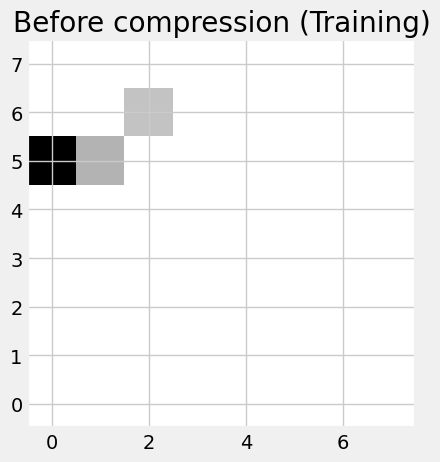

After compression (Training)
Shape: (1, 8, 8)


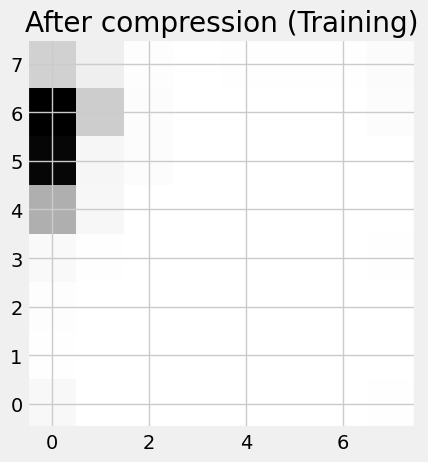

Before compression (Validation)
Shape: (64, 8, 8)


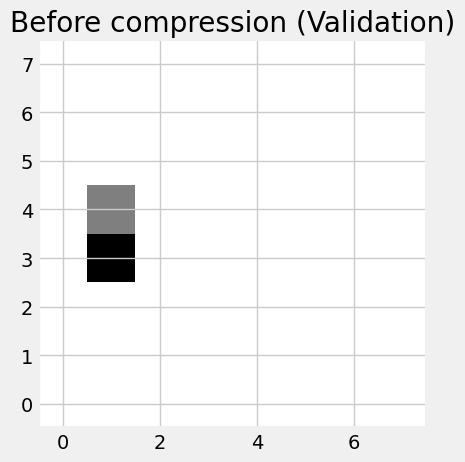

After compression (Validation)
Shape: (1, 8, 8)


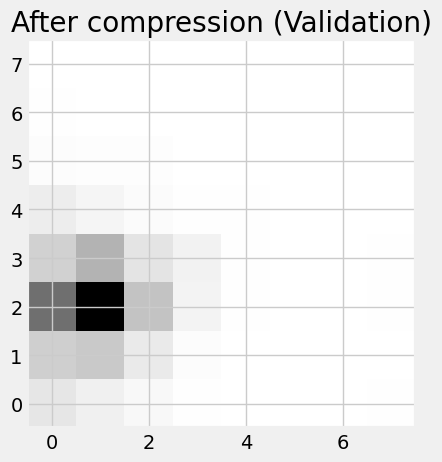

----------------------------------------
Patch = 0 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 2.449767783435422
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 31.0 (1 patch 8 x 8)
num_embeddings = 32
Codebook dimensions: 32 x 256
----------------------------------------


Epoch 2/80: 100%|██████████| 199/199 [00:00<00:00, 415.21it/s, Loss (BCE + VQ)=0.0821]


Epoch [2/80] summary:Average Loss: BCE = 0.0763, MSE = 0.005279308477482154 avg_perplexity = 17.006705480604314
Average validation set BCE loss: 0.04561892926692963


Epoch 3/80: 100%|██████████| 199/199 [00:00<00:00, 418.56it/s, Loss (BCE + VQ)=0.0626]


Epoch [3/80] summary:Average Loss: BCE = 0.0624, MSE = 0.004495625605282547 avg_perplexity = 20.486103398116988
Average validation set BCE loss: 0.04141762554645538


...

Epoch [14/80] summary:Average Loss: BCE = 0.0435, MSE = 0.00291807095031137 avg_perplexity = 22.845506898122817
Average validation set BCE loss: 0.03548546589910984


Epoch 15/80: 100%|██████████| 199/199 [00:00<00:00, 401.04it/s, Loss (BCE + VQ)=0.0399]


Epoch [15/80] summary:Average Loss: BCE = 0.0431, MSE = 0.002881048169412917 avg_perplexity = 24.457697623938174
Average validation set BCE loss: 0.0352620492875576


Epoch 16/80: 100%|██████████| 199/199 [00:00<00:00, 403.18it/s, Loss (BCE + VQ)=0.0428]


Epoch [16/80] summary:Average Loss: BCE = 0.0427, MSE = 0.002823753286522799 avg_perplexity = 24.36341686344626
Average validation set BCE loss: 0.035002270117402076
Before compression (Training)
Shape: (13, 8, 8)


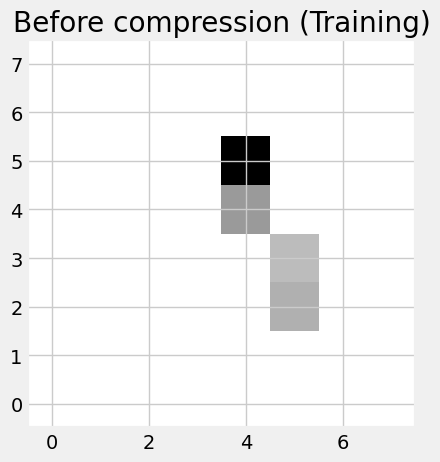

After compression (Training)
Shape: (1, 8, 8)


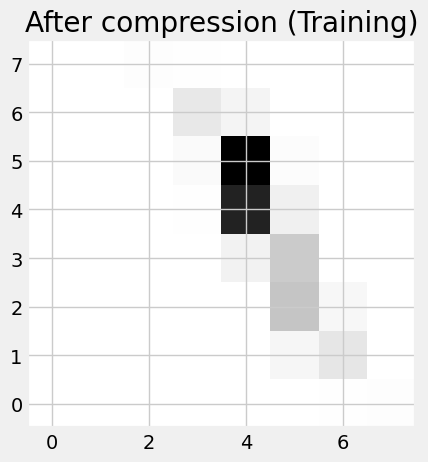

Before compression (Validation)
Shape: (64, 8, 8)


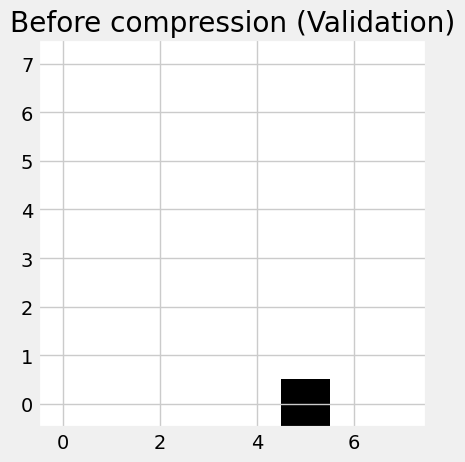

After compression (Validation)
Shape: (1, 8, 8)


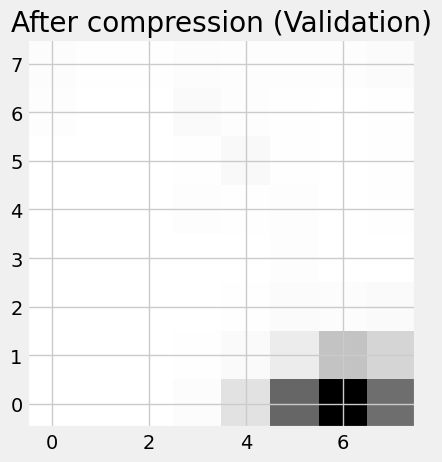

----------------------------------------
Patch = 1 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 2.449767783435422
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 31.0 (1 patch 8 x 8)
num_embeddings = 32
Codebook dimensions: 32 x 256
----------------------------------------


Epoch 17/80: 100%|██████████| 199/199 [00:00<00:00, 414.90it/s, Loss (BCE + VQ)=0.031] 


Epoch [17/80] summary:Average Loss: BCE = 0.0424, MSE = 0.0027975809863351997 avg_perplexity = 25.110995383717906
Average validation set BCE loss: 0.03498261690139771


Epoch 18/80: 100%|██████████| 199/199 [00:00<00:00, 404.32it/s, Loss (BCE + VQ)=0.0561]


Epoch [18/80] summary:Average Loss: BCE = 0.0421, MSE = 0.0027348007451059608 avg_perplexity = 25.524326151938894
Average validation set BCE loss: 0.03487234868109226


...

Epoch [29/80] summary:Average Loss: BCE = 0.0395, MSE = 0.002395276853056559 avg_perplexity = 25.170348430997763
Average validation set BCE loss: 0.03410835959017277


Epoch 30/80: 100%|██████████| 199/199 [00:00<00:00, 405.84it/s, Loss (BCE + VQ)=0.0542]


Epoch [30/80] summary:Average Loss: BCE = 0.0396, MSE = 0.0024198885140098146 avg_perplexity = 25.097484301083053
Average validation set BCE loss: 0.034123694002628324


Epoch 31/80: 100%|██████████| 199/199 [00:00<00:00, 425.87it/s, Loss (BCE + VQ)=0.0367]


Epoch [31/80] summary:Average Loss: BCE = 0.0391, MSE = 0.002365319220929514 avg_perplexity = 25.904372498018656
Average validation set BCE loss: 0.03397817328572273
Before compression (Training)
Shape: (13, 8, 8)


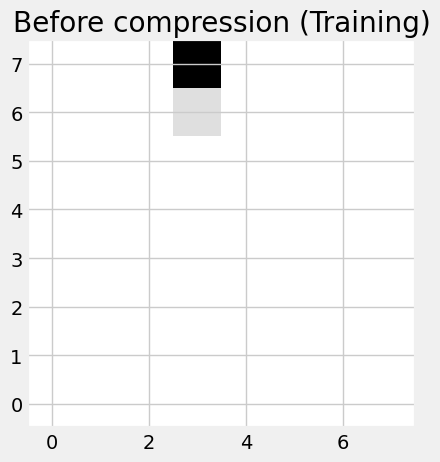

After compression (Training)
Shape: (1, 8, 8)


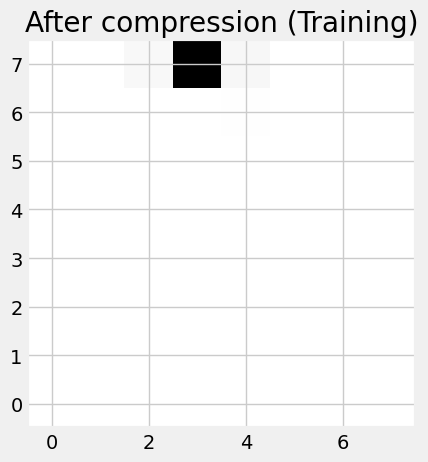

Before compression (Validation)
Shape: (64, 8, 8)


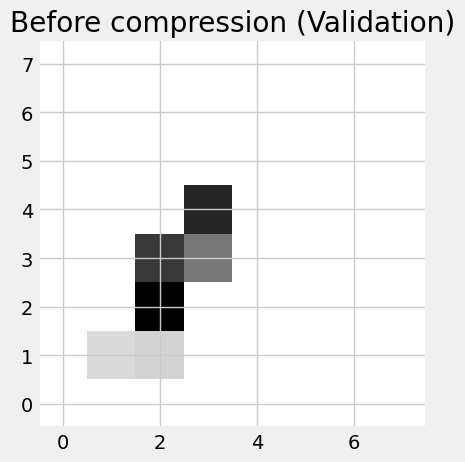

After compression (Validation)
Shape: (1, 8, 8)


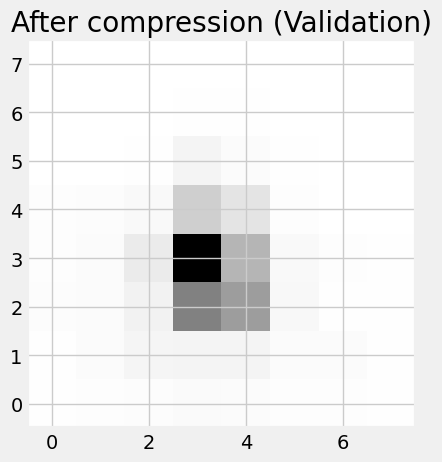

----------------------------------------
Patch = 2 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 2.449767783435422
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 31.0 (1 patch 8 x 8)
num_embeddings = 32
Codebook dimensions: 32 x 256
----------------------------------------


Epoch 32/80: 100%|██████████| 199/199 [00:00<00:00, 403.61it/s, Loss (BCE + VQ)=0.0508]


Epoch [32/80] summary:Average Loss: BCE = 0.0391, MSE = 0.002337666636159709 avg_perplexity = 26.47260388896693
Average validation set BCE loss: 0.033787511214613916


Epoch 33/80: 100%|██████████| 199/199 [00:00<00:00, 398.81it/s, Loss (BCE + VQ)=0.0297]


Epoch [33/80] summary:Average Loss: BCE = 0.0389, MSE = 0.0023299795002138346 avg_perplexity = 26.32240416176954
Average validation set BCE loss: 0.03399107411503792


...

Epoch [44/80] summary:Average Loss: BCE = 0.0376, MSE = 0.0021406631184339373 avg_perplexity = 26.305489094413105
Average validation set BCE loss: 0.033914723694324495


Epoch 45/80: 100%|██████████| 199/199 [00:00<00:00, 416.25it/s, Loss (BCE + VQ)=0.0326]


Epoch [45/80] summary:Average Loss: BCE = 0.0376, MSE = 0.002130058086851621 avg_perplexity = 26.296668105389006
Average validation set BCE loss: 0.03368884265422821


Epoch 46/80: 100%|██████████| 199/199 [00:00<00:00, 403.92it/s, Loss (BCE + VQ)=0.0401]


Epoch [46/80] summary:Average Loss: BCE = 0.0376, MSE = 0.0021118462616905344 avg_perplexity = 26.27088507455797
Average validation set BCE loss: 0.033601122573018075
Before compression (Training)
Shape: (13, 8, 8)


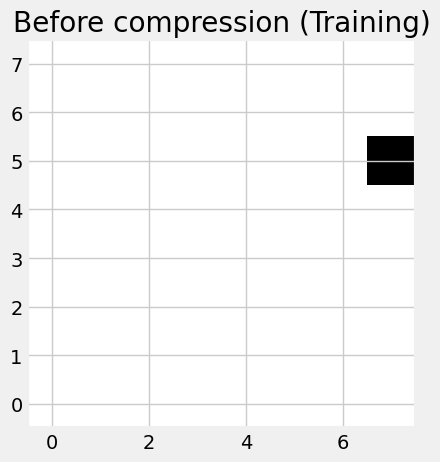

After compression (Training)
Shape: (1, 8, 8)


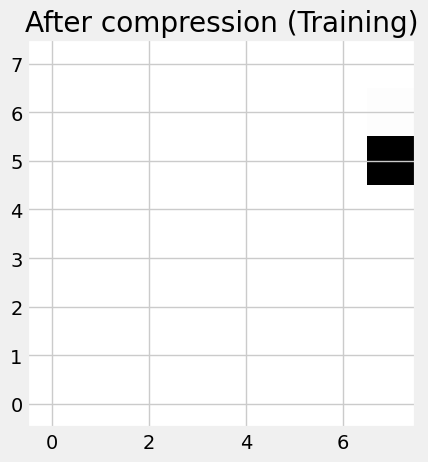

Before compression (Validation)
Shape: (64, 8, 8)


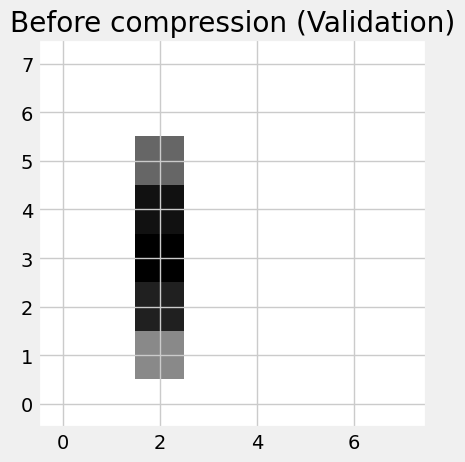

After compression (Validation)
Shape: (1, 8, 8)


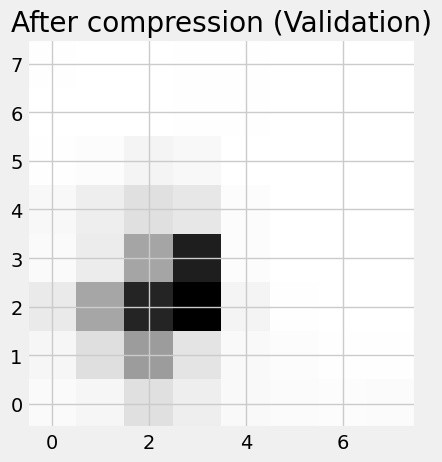

----------------------------------------
Patch = 3 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 2.449767783435422
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 31.0 (1 patch 8 x 8)
num_embeddings = 32
Codebook dimensions: 32 x 256
----------------------------------------


Epoch 47/80: 100%|██████████| 199/199 [00:00<00:00, 413.39it/s, Loss (BCE + VQ)=0.0585]


Epoch [47/80] summary:Average Loss: BCE = 0.0377, MSE = 0.0021102945893609793 avg_perplexity = 26.280837629308653
Average validation set BCE loss: 0.033949168175458906


Epoch 48/80: 100%|██████████| 199/199 [00:00<00:00, 421.48it/s, Loss (BCE + VQ)=0.0212]


Epoch [48/80] summary:Average Loss: BCE = 0.0376, MSE = 0.002094242218694645 avg_perplexity = 26.300138454341408
Average validation set BCE loss: 0.03377935059368611


...

Epoch [59/80] summary:Average Loss: BCE = 0.0366, MSE = 0.001936933121072999 avg_perplexity = 26.26705189805534
Average validation set BCE loss: 0.03366432145237923


Epoch 60/80: 100%|██████████| 199/199 [00:00<00:00, 404.17it/s, Loss (BCE + VQ)=0.0384]


Epoch [60/80] summary:Average Loss: BCE = 0.0363, MSE = 0.0018933892069295534 avg_perplexity = 26.26287094192888
Average validation set BCE loss: 0.03356307715177536


Epoch 61/80: 100%|██████████| 199/199 [00:00<00:00, 410.98it/s, Loss (BCE + VQ)=0.0499]


Epoch [61/80] summary:Average Loss: BCE = 0.0368, MSE = 0.0019545484780001655 avg_perplexity = 26.2329195108845
Average validation set BCE loss: 0.03400593154132366
Before compression (Training)
Shape: (13, 8, 8)


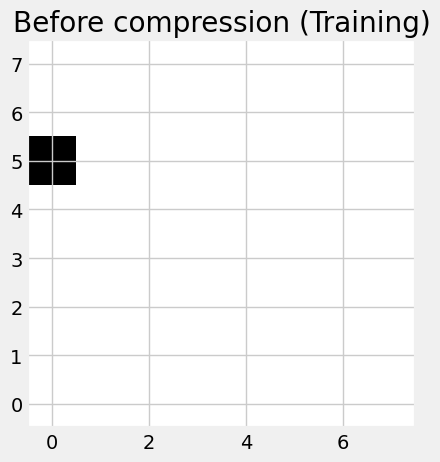

After compression (Training)
Shape: (1, 8, 8)


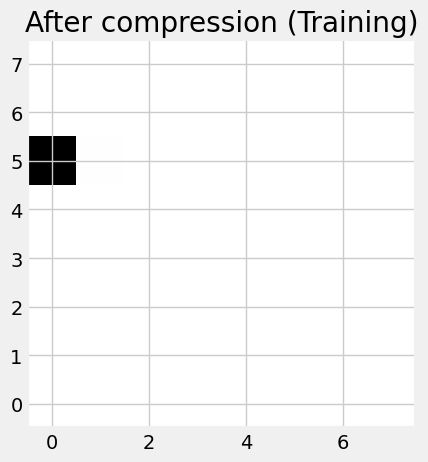

Before compression (Validation)
Shape: (64, 8, 8)


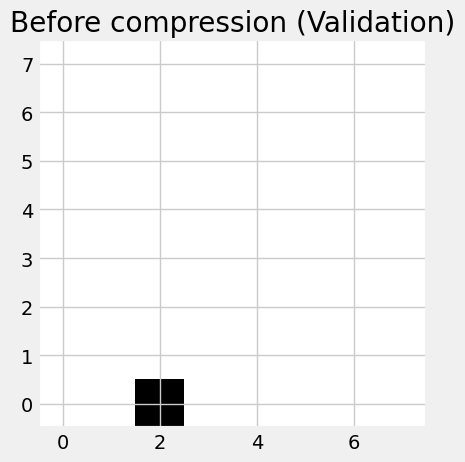

After compression (Validation)
Shape: (1, 8, 8)


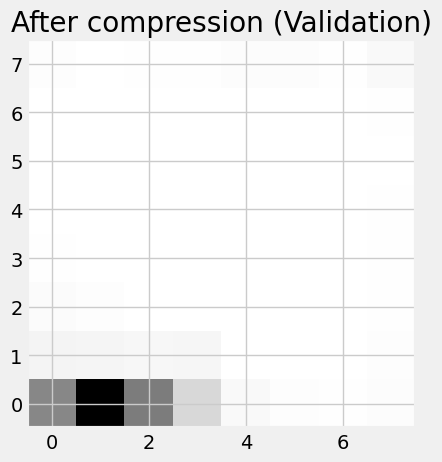

----------------------------------------
Patch = 4 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 2.449767783435422
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 31.0 (1 patch 8 x 8)
num_embeddings = 32
Codebook dimensions: 32 x 256
----------------------------------------


Epoch 62/80: 100%|██████████| 199/199 [00:00<00:00, 409.68it/s, Loss (BCE + VQ)=0.0337]


Epoch [62/80] summary:Average Loss: BCE = 0.0363, MSE = 0.0018986137074900407 avg_perplexity = 26.2377912530947
Average validation set BCE loss: 0.033882350772619245


Epoch 63/80: 100%|██████████| 199/199 [00:00<00:00, 416.51it/s, Loss (BCE + VQ)=0.0312]


Epoch [63/80] summary:Average Loss: BCE = 0.0363, MSE = 0.001879310668282323 avg_perplexity = 26.289301637429087
Average validation set BCE loss: 0.03378437384963036


...

Epoch [74/80] summary:Average Loss: BCE = 0.0357, MSE = 0.0017858177786763177 avg_perplexity = 26.478710212899212
Average validation set BCE loss: 0.034205505102872846


Epoch 75/80: 100%|██████████| 199/199 [00:00<00:00, 396.61it/s, Loss (BCE + VQ)=0.0424]


Epoch [75/80] summary:Average Loss: BCE = 0.0358, MSE = 0.0017749853952829936 avg_perplexity = 26.51213406318396
Average validation set BCE loss: 0.03412521541118622


Epoch 76/80: 100%|██████████| 199/199 [00:00<00:00, 397.35it/s, Loss (BCE + VQ)=0.0365]


Epoch [76/80] summary:Average Loss: BCE = 0.0356, MSE = 0.0017833686381082364 avg_perplexity = 26.749010344845566
Average validation set BCE loss: 0.033645941391587254
Before compression (Training)
Shape: (13, 8, 8)


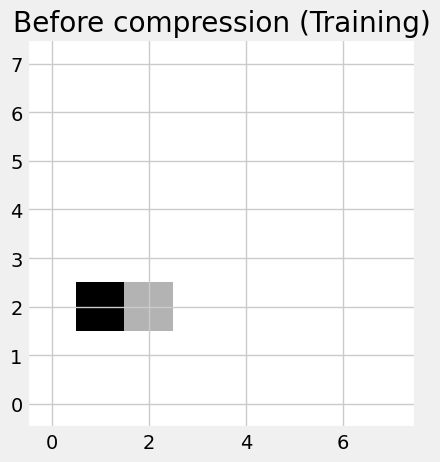

After compression (Training)
Shape: (1, 8, 8)


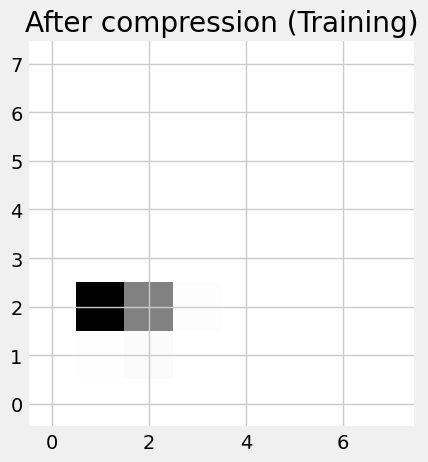

Before compression (Validation)
Shape: (64, 8, 8)


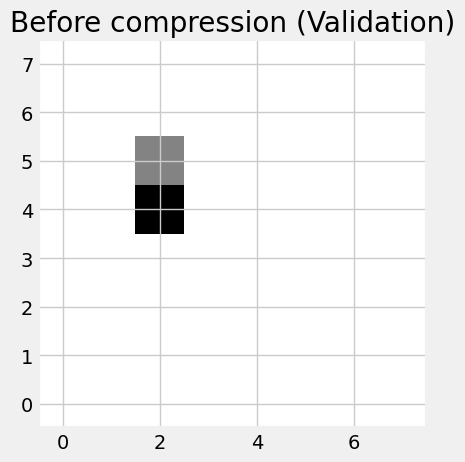

After compression (Validation)
Shape: (1, 8, 8)


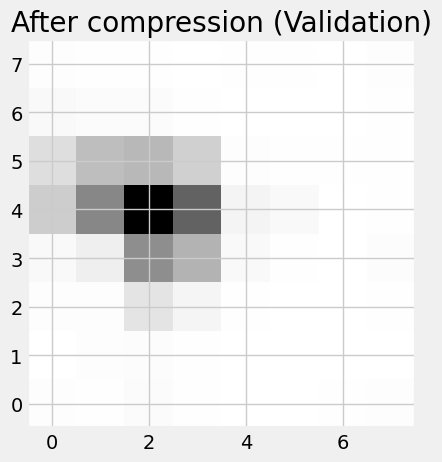

----------------------------------------
Patch = 5 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 2.449767783435422
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 31.0 (1 patch 8 x 8)
num_embeddings = 32
Codebook dimensions: 32 x 256
----------------------------------------


Epoch 77/80: 100%|██████████| 199/199 [00:00<00:00, 398.75it/s, Loss (BCE + VQ)=0.0415]


Epoch [77/80] summary:Average Loss: BCE = 0.0357, MSE = 0.0017715987828957975 avg_perplexity = 26.814979591561322
Average validation set BCE loss: 0.033589300140738486


Epoch 78/80: 100%|██████████| 199/199 [00:00<00:00, 403.82it/s, Loss (BCE + VQ)=0.0466]


Epoch [78/80] summary:Average Loss: BCE = 0.0355, MSE = 0.001728060878181465 avg_perplexity = 26.898860490501825
Average validation set BCE loss: 0.03370849072933197


Epoch 79/80: 100%|██████████| 199/199 [00:00<00:00, 399.35it/s, Loss (BCE + VQ)=0.0341]


Epoch [79/80] summary:Average Loss: BCE = 0.0353, MSE = 0.001719052131444534 avg_perplexity = 26.907862313428716
Average validation set BCE loss: 0.03389960736036301


Epoch 80/80: 100%|██████████| 199/199 [00:00<00:00, 417.25it/s, Loss (BCE + VQ)=0.0263]


Epoch [80/80] summary:Average Loss: BCE = 0.0355, MSE = 0.0017286866719614547 avg_perplexity = 26.971894800962517
Average validation set BCE loss: 0.033535597771406175
Saving trained model VQ-VAE


In [54]:
# BCE loss average values
average_loss_train = []
average_loss_values_val = []

# Patches (validation)
patches_before_val = []
patches_after_val = []
patches_encodings_val = [] # latent vector
patches_pairs_val = []

# Patches (training)
patches_before_train = []
patches_encodings_train = []
patches_after_train = []

# MSE residual averages
average_loss_train_mse = []
average_loss_valid_mse_val = []

# perplexity
average_perplexity_train = []
average_perplexity_val = []

plot_val_patches_limit = 15
plot_idx = 0


for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_loss_mse = 0
    train_perplexity = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        X_adcs = X_adcs.to(device)
        
        (
            recon_patch, 
            codebook_train,
            _,
            perplexity,
            vq_loss
        ) = model(
           X_adcs
        )
        
        
        bce_loss = _get_vae_loss(recon_patch, X_adcs)
        total_vq_loss = bce_loss + vq_loss
        
        recon_patch_train = recon_patch.float().to(device)      
        train_loss += total_vq_loss.item()
        
        total_vq_loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=model_param_scale)
        
        train_loss_mse += mse(recon_patch_train, X_adcs).item()
        train_perplexity += perplexity.item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss (BCE + VQ)': total_vq_loss.item()})
        # scheduler.step()
        
        
    avg_loss_bce_vq = train_loss / len(train_loader)
    avg_loss_mse = train_loss_mse / len(train_loader)
    avg_perplexity = train_perplexity / len(train_loader)
    
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] summary:"
        f"Average Loss: BCE = {avg_loss_bce_vq:.4f}, "
        f"MSE = {avg_loss_mse}",
        f"avg_perplexity = {avg_perplexity}"
    )
    
    average_loss_train.append(avg_loss_bce_vq)
    average_loss_train_mse.append(avg_loss_mse)
    average_perplexity_train.append(avg_perplexity)
    
    # Test with validation set for checking error residuals
    with torch.no_grad():
        model.eval()
        total_bce_loss_val = 0
        total_mse_loss_val = 0
        
        # Calculating average erros 
        for patch_val in val_loader:
            patch_val = patch_val.to(device)  
            
            (
               recon_patch_val, 
               codebook_val, 
               z_q_val,
               perplexity_val,
               _,
            ) = model(patch_val)
            
            patch_bce_val = F.binary_cross_entropy(
                recon_patch_val,
                patch_val,
                reduction="mean"
            ).cpu().detach().numpy().item()
            total_bce_loss_val += patch_bce_val
            
            patch_mse_val = mse(
               patch_val,
               recon_patch_val  
            ).item()
            total_mse_loss_val += patch_mse_val
            
            # result = _get_compression_ratio_vae(
            #     total_hit_amount, 
            #     patch_amount,
            #     zhidden_channels * 2
            # )
        
        average_loss_val = total_bce_loss_val / len(val_loader)
        average_loss_val_mse = total_mse_loss_val / len(val_loader)
        average_loss_values_val.append(average_loss_val)
        average_loss_valid_mse_val.append(average_loss_val_mse)
        
        print(f"Average validation set BCE loss: {average_loss_val}")
        # print("Last batch patch, compression metrics:")
        # for k, v in result.items():
        #     print(f"{k} = {v}")
    
        # Test with validation set for checking image reconstruction quality
    
        if epoch % LOG_EVERY == 0:
                # selecting events before reconstruction using one test loader as validation
                # plotting last training
                
                print("Before compression (Training)")                    
                X_adcs_ts = _tensor_to_numpy(
                    X_adcs.squeeze(1)
                )
                
                print(f"Shape: {X_adcs_ts.shape}")            
                plot_patch(X_adcs_ts[0], "Before compression (Training)")
                
                recon_patch_train_np = _tensor_to_numpy(
                    recon_patch_train[0]
                )
                print("After compression (Training)")
                print(f"Shape: {recon_patch_train_np.shape}")
                
                plot_patch(recon_patch_train_np[0], "After compression (Training)")
                
                if len(patches_after_train) < plot_val_patches_limit:
                    patches_before_train.append(X_adcs_ts[0])
                    patches_after_train.append(recon_patch_train_np[0])
                    patches_encodings_train.append(_tensor_to_numpy(codebook_train))
                
                for patch_val in val_loader:
                    patch_val = patch_val.to(device)           
                    
                    (
                        recon_patch_val, 
                        codebook_val, 
                        z_q_val, 
                        perplexity_val,
                        _
                    ) = model(patch_val)
                    
                    if len(patches_pairs_val) < plot_val_patches_limit:
                        patches_pairs_val.append(
                            (
                                patch_val, 
                                z_q_val, 
                                recon_patch_val, 
                                codebook_val
                            )
                        )
                
                if plot_idx < len(patches_pairs_val):
                    (
                        patch_val, 
                        z_q_val, 
                        recon_patch_val, 
                        codebook_val
                    ) = patches_pairs_val[plot_idx]
                    
                    print("Before compression (Validation)")                    
                    patch_val_ts_val = _tensor_to_numpy(
                        patch_val.squeeze(1)
                    )
                    
                    print(f"Shape: {patch_val_ts_val.shape}")            
                    plot_patch(patch_val_ts_val[0], "Before compression (Validation)")
                    
                    patches_before_val.append(patch_val_ts_val[0])
                    
                    recon_patch_np_val = _tensor_to_numpy(
                        recon_patch_val[0]
                    )
                    print("After compression (Validation)")
                    print(f"Shape: {recon_patch_np_val.shape}")
                    
                    plot_patch(recon_patch_np_val[0], "After compression (Validation)")
                
                    patches_after_val.append(recon_patch_np_val[0])  
                    encodings_val_np = _tensor_to_numpy(codebook_val)
                    patches_encodings_val.append(encodings_val_np) 
                    
                    width_val, height_val = z_q_val[0][0].shape
                    c_width, c_height = codebook_val.shape
                    
                    print("----------------------------------------")
                    print(f"Patch = {plot_idx} compression results")
                    print("----------------------------------------")
                    print(
                        f"Patch encoder output dimensions:"
                        f"(w x h) = ({width_val}) x ({height_val})"
                    )
                    
                    compression_ratio = _get_compression_ratio(
                        n_hits_total=total_hit_amount,
                        patch_amount=patch_amount,
                        encoded_patch_size=(width_val, height_val, num_embeddings),
                        patch_size=PATCH_SIZE
                    )
                    total_bits = _get_total_hit_bits(total_hit_amount)
                    encoded_patch_bits = _get_encoded_patch_bits(
                        (width_val, height_val, num_embeddings), 
                        PATCH_SIZE
                    )
                    
                    print(f"Compression ratio = {compression_ratio}")
                    print(f"total_hit_amount = {total_hit_amount}")
                    print(f"total_hit_bits = {total_bits}")
                    print(f"patch_amount = {patch_amount}")
                    print(f"encoded_patch_bits = {encoded_patch_bits} (1 patch {PATCH_SIZE} x {PATCH_SIZE})")
                    print(f"num_embeddings = {num_embeddings}")
                    print(f"Codebook dimensions: {c_width} x {c_height}")
                    print("----------------------------------------")
                    
                    plot_idx += 1        
            
# save model
print("Saving trained model VQ-VAE")
torch.save(model.state_dict(), "vqvae.pth")

In [55]:
# logvar_values = logvar.detach().cpu().flatten().numpy()
# # histogram
# plt.hist(logvar_values, bins=50)

# plt.title("VAE Latent logvar Distribution")
# plt.xlabel("logvar")
# plt.ylabel("count")

# plt.show()

In [56]:
# TODO
# Compression ratio calculation
# Find total sum of hit bits
# Find total sum of encoded patch bits
total_bits = _get_total_hit_bits(total_hit_amount)


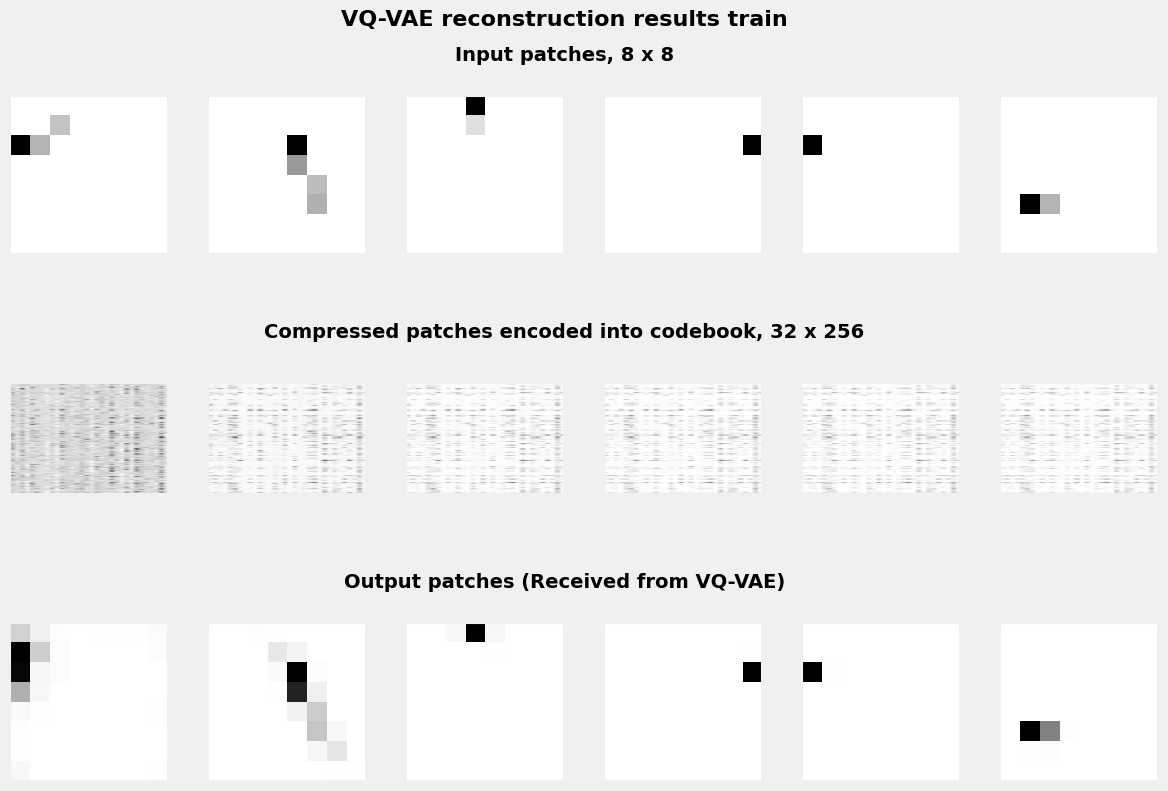

In [57]:
def plot_patches(patch_rows: list[tuple], title: str) -> None:
    cols = len(patch_rows[0][0])
    rows = len(patch_rows)

    fig = plt.figure(figsize=(2.2 * cols, 8.5))

    gs = GridSpec(
        rows,
        cols,
        figure=fig,
        height_ratios=[1.2, 1.0, 1.2],
        wspace=0.25,
        hspace=0.75
    )

    fig.suptitle(
        title,
        fontsize=16,
        fontweight="bold",
        y=0.98
    )

    for i in range(rows):
        patch_row, patch_row_title = patch_rows[i]

        # Row title aligned above each row
        row_top = gs[i, :].get_position(fig).y1
        fig.text(
            0.5,
            row_top + 0.035,
            patch_row_title,
            ha="center",
            va="bottom",
            fontsize=14,
            fontweight="bold"
        )

        for j in range(cols):
            ax = fig.add_subplot(gs[i, j])

            patch = patch_row[j]

            # Keep your current row-1 transpose logic
            if i == 1:
                patch = patch.T

                im = ax.imshow(
                    patch,
                    cmap="gist_yarg",
                    origin="lower",
                    aspect="auto"
                )

                # Make codebook row rectangular but aligned inside same column
                ax.set_box_aspect(0.7)

            else:
                im = ax.imshow(
                    patch,
                    cmap="gist_yarg",
                    origin="lower",
                    aspect="equal"
                )

                # Square input/output patches
                ax.set_box_aspect(1.0)

            ax.set_xticks([])
            ax.set_yticks([])

            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.5)

    plt.show()
        
        
patch_rows = [
    (patches_before_train, "Input patches, 8 x 8"),
    (
        patches_encodings_train, 
        f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
    ),
    (patches_after_train, "Output patches (Received from VQ-VAE)")
]

plot_patches(patch_rows, "VQ-VAE reconstruction results train")

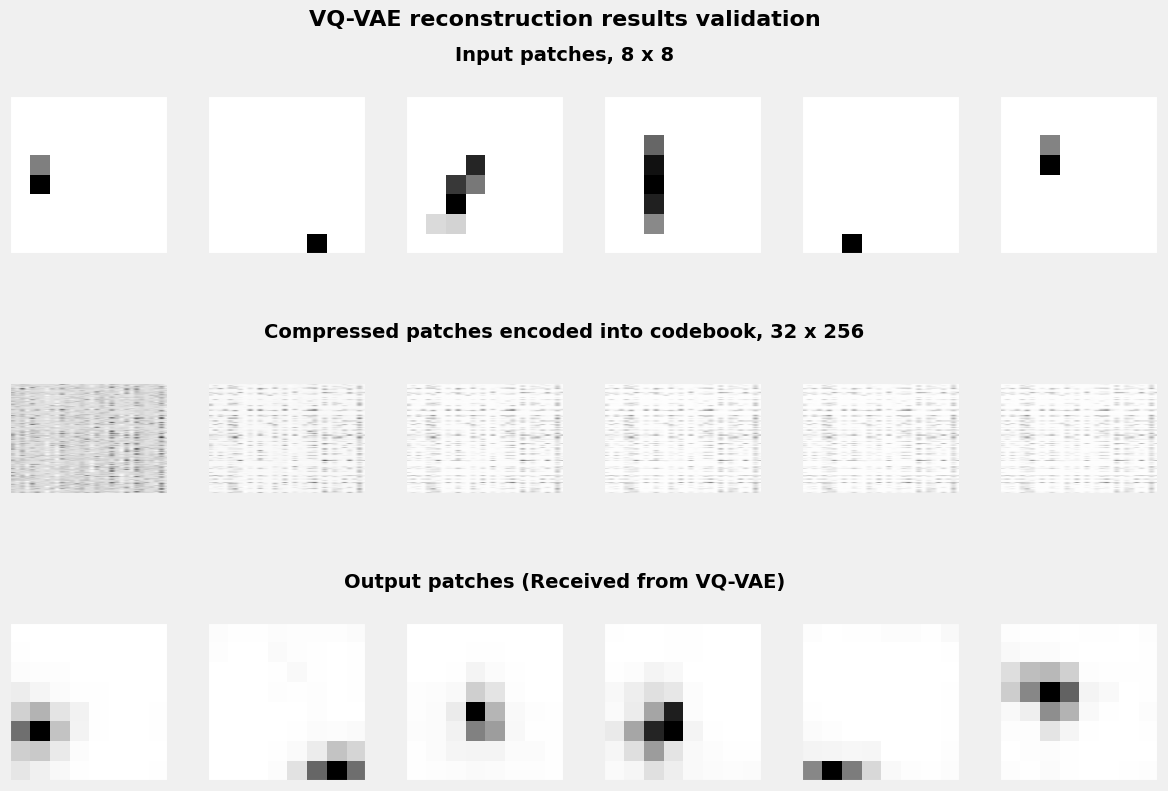

In [58]:
patch_rows = [
    (patches_before_val, "Input patches, 8 x 8"),
    (patches_encodings_val, 
     f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
     ),
    (patches_after_val, "Output patches (Received from VQ-VAE)")
]

plot_patches(patch_rows, "VQ-VAE reconstruction results validation")

In [59]:
# TODO
# Improve gradients
_display_gradients(model)

Showing model gradients
encoder.0.weight 0.016880566254258156
encoder.1.weight 0.0018534513656049967
encoder.1.bias 0.003426463110372424
encoder.3.weight 0.025149419903755188
encoder.4.weight 0.0017514129867777228
encoder.4.bias 0.0020563900470733643
encoder.6.weight 0.01760161854326725
encoder.7.weight 0.001426342991180718
encoder.7.bias 0.002294125035405159
encoder.8.stack.0.res_block.1.weight 0.013871592469513416
encoder.8.stack.0.res_block.3.weight 0.006787151098251343
encoder.8.stack.1.res_block.1.weight 0.010786585509777069
encoder.8.stack.1.res_block.3.weight 0.004177330061793327
vq_layer.embedding.weight 0.0003027701750397682
decoder.0.weight 0.003927240613847971
decoder.1.weight 0.0007262134458869696
decoder.1.bias 0.0004742825694847852
decoder.2.stack.0.res_block.1.weight 0.003089511301368475
decoder.2.stack.0.res_block.3.weight 0.0038985044229775667
decoder.2.stack.1.res_block.1.weight 0.005621471907943487
decoder.2.stack.1.res_block.3.weight 0.008539654314517975
decoder.3.w

VQ VAE, BCE encoder average loss values over epochs


/tmp/ipykernel_434186/831797292.py:94: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


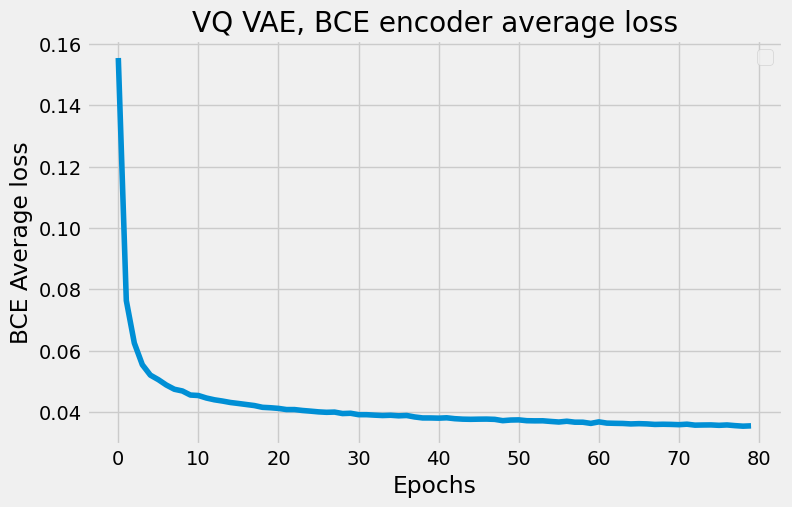

In [60]:
# display loss values
plot_metric_results(
    y_values=average_loss_train, 
    x_values=list(range(num_epochs)),
    y_title="BCE Average loss",
    title="VQ VAE, BCE encoder average loss",
    x_label="Epochs"
)

In [61]:
# print(f"mu = {model.z_log_mean.mean().item()}")
# print(f"logvar = {model.z_log_var.std().item()}")

In [62]:
# Test set for testing using unseen data
model.load_state_dict(torch.load("vqvae.pth"))
model.eval()

bce_loss_values_test = []

patch_display_limit = 8
patches_after_test = []
patches_before_test = []
patches_encodings_test = [] # latent vector

bce_total_value = 0
perplexity_total = 0
test_set_size = len(test_loader)

for patch_test in test_loader:
    patch_test = patch_test.to(device)                     
    (
        recon_patch, 
        codebook_test, 
        z_q, 
        perplexity,
        _
    ) = model(patch_test)
    
    perplexity_total += perplexity.item()
    
    if len(patches_after_test) < patch_display_limit:
        patch_test_np = patch_test[0][0].cpu().detach().numpy()
        patches_before_test.append(patch_test_np)
        
        recon_patch_np = recon_patch[0][0].cpu().detach().numpy()
        patches_after_test.append(recon_patch_np)
        patches_encodings_test.append(_tensor_to_numpy(codebook_test))
    
    # mse_loss = F.mse_loss(patch_test, recon_patch).item()
    bce_loss = F.binary_cross_entropy(
        patch_test, 
        recon_patch, 
        reduction="mean"
    ).cpu().detach().numpy().item()
    
    bce_total_value += bce_loss
    
bce_loss_average = bce_total_value / test_set_size
perplexity_average = perplexity_total / test_set_size

print(f"Based on test set (size = {test_set_size}), average BCE loss = {bce_loss_average:.5f}")
print(f"Based on test set (size = {test_set_size}), average codebook perplexity = {perplexity_average:.5f}/{num_embeddings}")

Based on test set (size = 25), average BCE loss = 0.29142
Based on test set (size = 25), average codebook perplexity = 26.80563/32


In [63]:
len(patches_before_test)

8

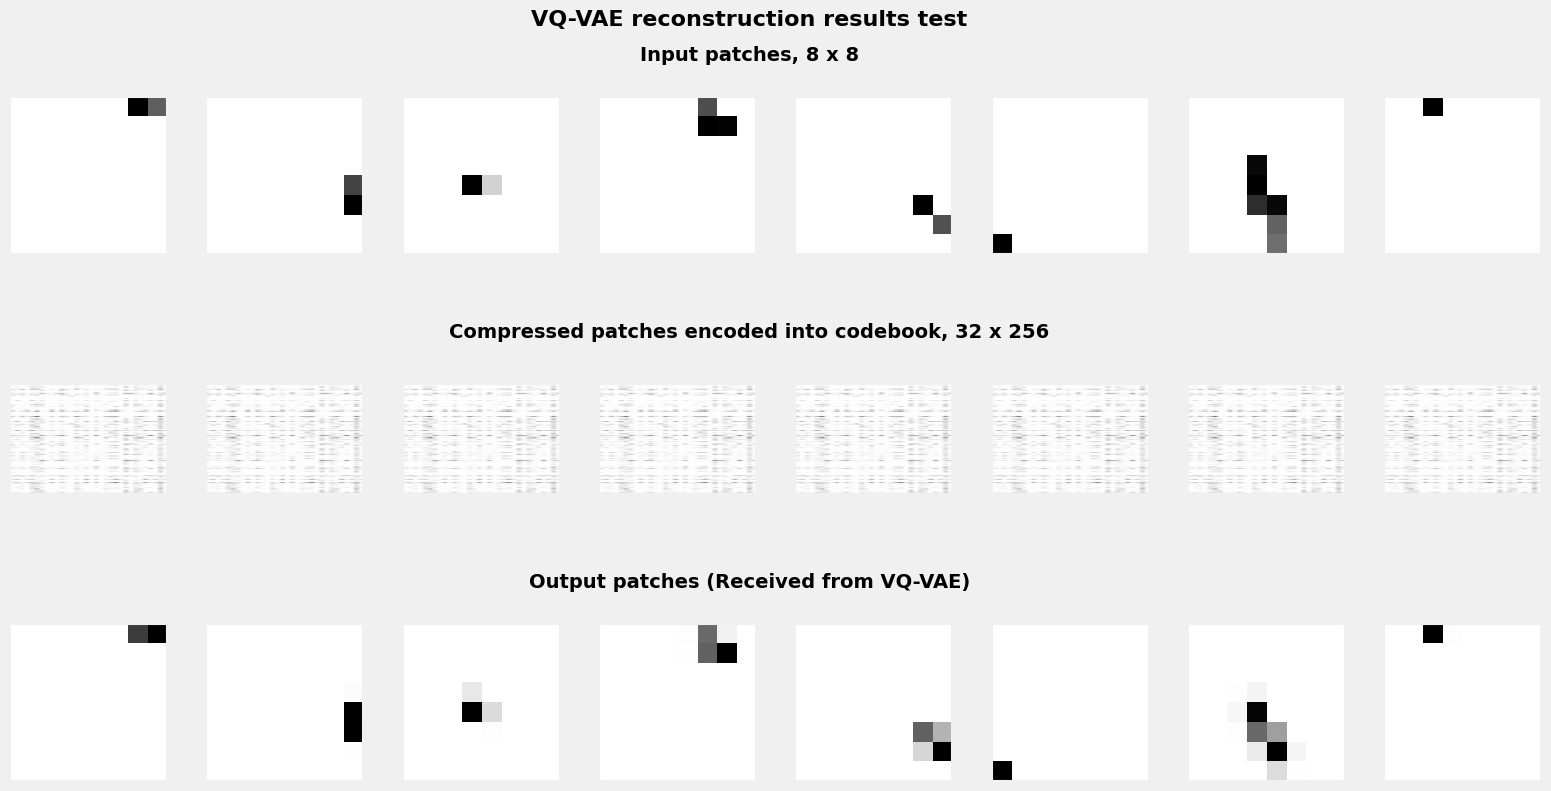

In [64]:
# Test dataset plotting part
patch_rows = [
    (patches_before_test, "Input patches, 8 x 8"),
    (patches_encodings_test, f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"),
    (patches_after_test, "Output patches (Received from VQ-VAE)")
]

plot_patches(patch_rows, "VQ-VAE reconstruction results test")

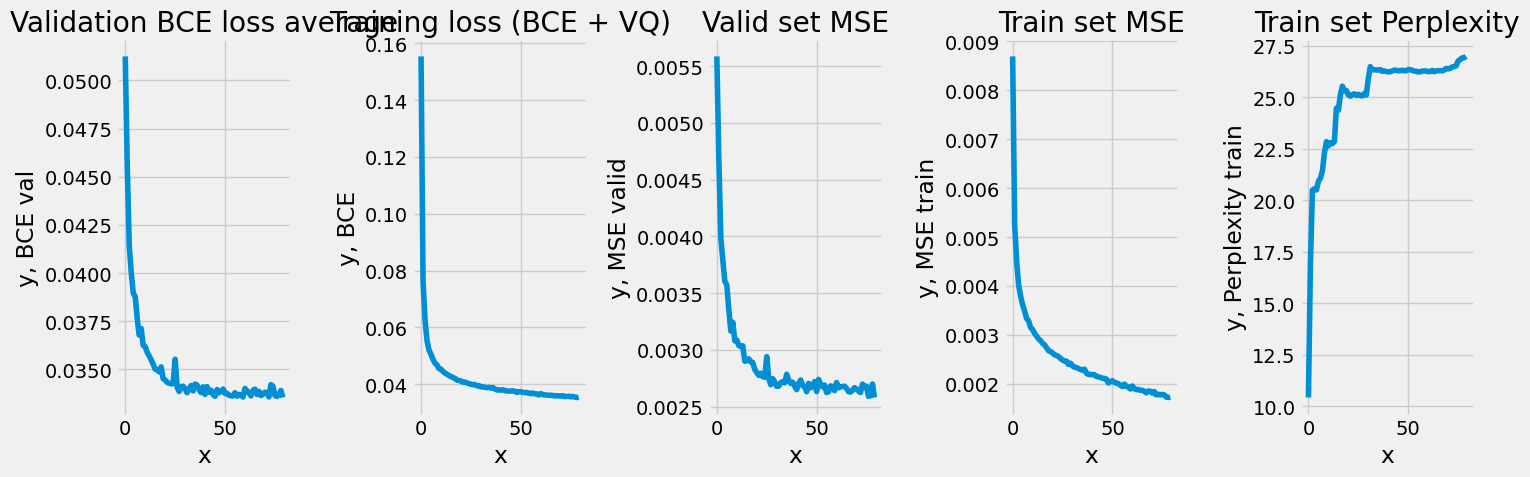

In [65]:
values_to_plot = [
    (list(range(len(average_loss_values_val))), average_loss_values_val, "Validation BCE loss average", "BCE val"),
    (list(range(len(average_loss_train))), average_loss_train, "Training loss (BCE + VQ)", "BCE"),
    (list(range(len(average_loss_valid_mse_val))), average_loss_valid_mse_val, "Valid set MSE", "MSE valid"),
    (list(range(len(average_loss_train_mse))), average_loss_train_mse, "Train set MSE", "MSE train"),
    (list(range(len(average_perplexity_train))), average_perplexity_train, "Train set Perplexity", "Perplexity train"),
]

fig, axes = plt.subplots(1, len(values_to_plot), figsize=(15, 5))

for i, (x, y, title, y_label) in enumerate(values_to_plot):
    axes[i].plot(
        x,
        y,
    )
    axes[i].grid(True)
    axes[i].set_title(title)
    axes[i].set_xlabel("x")
    axes[i].set_ylabel(f"y, {y_label}")
    
    for spine in axes[i].spines.values():
        spine.set_linewidth(2)

plt.tight_layout()
plt.show()

# print(title + " values over epochs")
# plt.style.use('fivethirtyeight')
# plt.figure(figsize=(8, 5))
# plt.plot(x_values, y_values, marker=marker)
# plt.xlabel(x_label)
# plt.ylabel(y_title)
# plt.legend()
# plt.title(title)
# plt.show()

Results:
<!-- * Perplexity shows that per patch about 10 from 16 codebook entries are used
* Reconstruction quality is about average. Representations with validation and test tests
look marginally similar to the input images
* Compression ratio shows that input image successfully was scaled about 3 times (~2.8).
* 1 encoded patch has 27 bits, while 1 encoded patch in VAE has 128 bits. 
* beta = 4e-3 (commitment cost) given better results. Beta needs to be very small and once smaller, gives better results. Based on official VQ-VAE research paper, image compression, requires beta to in the inverval [0.1, 2.0] -->
* Codebook entries from 16 vectors (rows), only approximately 8 codebook entries are used based perplexity
* Reconstruction improves with bigger latent vector and num embeddings. Reducing codebook size, improves usage but not reconstruction
* Validation set properly works with higher beta coeficient